In [18]:
# Scaling and normalization: fit on train only, applied at model-training time (see note below)


In [19]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## Load merged features

Import `pm25_all_features_merged.csv` and drop static columns (single-value geographic/metadata fields that do not vary across rows).

In [20]:
df = pd.read_csv("pm25_all_features_merged.csv", parse_dates=["date"])
print(f"Loaded pm25_all_features_merged.csv: {df.shape}")

static_columns = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]
df = df.drop(columns=static_columns)

print(f"Removed {len(static_columns)} static column(s):")
print(static_columns)
print(f"Combined shape after drop: {df.shape}")

df.head()

Loaded pm25_all_features_merged.csv: (1825, 49)
Removed 16 static column(s):
['station', 'city', 'local_authority', 'zone', 'agglomeration', 'environment', 'latitude', 'longitude', 'country', 'spatial_cluster', 'spatial_cluster_code', 'environment_code', 'is_urban', 'is_roadside', 'morning_peak_hour', 'evening_peak_hour']
Combined shape after drop: (1825, 33)


,date,pm25,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,...,pm25_rollmean3,pm25_rollstd3,O3,NO,NO2,NOx,CO,PM10,day_of_week_y,quarter_num
0,2021-01-01,17.167,2021,1,1,4,1,53,1,0,...,17.167000,NaN,14.168778,21.136486,29.890934,62.299762,0.330584,21.254,4,1
1,2021-01-02,5.167,2021,1,2,5,2,53,1,1,...,11.167000,8.485281,21.778473,11.243936,24.353095,41.593555,0.243317,7.629,5,1
2,2021-01-03,4.500,2021,1,3,6,3,53,1,1,...,8.944667,7.128555,25.285105,6.264511,16.727747,26.333197,0.120144,7.838,6,1
3,2021-01-04,3.458,2021,1,4,0,4,1,1,0,...,4.375000,0.861330,35.145802,3.982668,13.439898,19.546571,0.132458,7.171,0,1
4,2021-01-05,3.250,2021,1,5,1,5,1,1,0,...,3.736000,0.669767,29.900160,6.389799,15.996390,25.793945,0.098882,7.671,1,1


## Add meteorological features

Merge the model-ready table `meteorological/london_meteorological_features.csv` onto the loaded feature table. That export already keeps only measured daily features (IQR outlier flags, imputation flags, and `hourly_obs_count` stay in the per-variable `london_*_features.csv` files).


In [21]:
n_before = len(df)
meteo = pd.read_csv(
    "meteorological/london_meteorological_features.csv",
    parse_dates=["date"],
)
df = df.merge(meteo, on="date", how="left")

print(f"Merged london_meteorological_features.csv: +{meteo.shape[1] - 1} columns")
print(f"Rows: {n_before} -> {len(df)}")
print(f"Shape after meteorological merge: {df.shape}")
df.head()


Merged london_meteorological_features.csv: +16 columns
Rows: 1825 -> 1825
Shape after meteorological merge: (1825, 49)


,date,pm25,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,...,mean_air_pressure_hpa,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg
0,2021-01-01,17.167,2021,1,1,4,1,53,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,5.167,2021,1,2,5,2,53,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,4.500,2021,1,3,6,3,53,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,3.458,2021,1,4,0,4,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,3.250,2021,1,5,1,5,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Check column types

Flag columns that are not numeric or boolean before modelling (e.g. dates, strings, categories).

In [22]:
non_numeric_non_bool = [
    col for col in df.columns
    if not pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col])
]

print(f"Non-numeric / non-boolean columns ({len(non_numeric_non_bool)}):")
print(non_numeric_non_bool)

if non_numeric_non_bool:
    print("\nDtypes:")
    print(df[non_numeric_non_bool].dtypes)
    print("\nSample values:")
    print(df[non_numeric_non_bool].head())
else:
    print("All columns are numeric or boolean.")

Non-numeric / non-boolean columns (2):
['date', 'season']

Dtypes:
date      datetime64[us]
season               str
dtype: object

Sample values:
        date  season
0 2021-01-01  Winter
1 2021-01-02  Winter
2 2021-01-03  Winter
3 2021-01-04  Winter
4 2021-01-05  Winter


### Drop `season`

The string `season` column (Winter, Spring, Summer, Autumn) is redundant for modelling. The ordinal `season_code` feature (0–3) encodes the same seasonal information in numeric form, so we keep `season_code` and drop `season`.

In [23]:
df = df.drop(columns=["season"])
print("Dropped 'season', kept season_code for training")
print(f"Shape: {df.shape}")

Dropped 'season', kept season_code for training
Shape: (1825, 48)


## Sync with cleaned target

Align the combined feature table to the cleaned London Marylebone Road PM2.5 series (`data/target_data/cleaned_london_marylebone_pm25.csv`).

Keep only dates present in the cleaned target, and replace `pm25` with the cleaned values.


In [24]:
df = df.drop(columns=["pm25"])
print(f"Dropped pm25; shape: {df.shape}")


Dropped pm25; shape: (1825, 47)


In [25]:
pm25_target = pd.read_csv(
    "../data/target_data/cleaned_london_marylebone_pm25.csv",
    parse_dates=["date"],
)
n_before = len(df)

df = (
    df.merge(pm25_target, on="date", how="inner")
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Rows before sync: {n_before}")
print(f"Rows after sync: {len(df)}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head()


Rows before sync: 1825
Rows after sync: 1364
Date range: 2022-04-07 to 2025-12-30


,date,year,month,day_of_month,day_of_week_x,day_of_year,week_of_year,quarter,is_weekend,is_weekday,...,air_pressure_max_hpa,air_pressure_min_hpa,temperature_max_c,temperature_min_c,temperature_avg_c,mean_wind_speed_knots,wind_speed_max_knots,wind_speed_min_knots,wind_direction_deg,pm25
0,2022-04-07,2022,4,7,3,97,14,2,0,1,...,1000.9,983.9,13.59414,6.81972,10.206930,13.000000,16.0,4.0,270.636089,5.53
1,2022-04-08,2022,4,8,4,98,14,2,0,1,...,1008.6,997.8,11.35049,1.85771,6.604100,4.291667,9.0,1.0,16.779591,6.72
2,2022-04-09,2022,4,9,5,99,14,2,1,0,...,1019.1,1009.7,12.38106,0.59361,6.487335,5.458333,9.0,3.0,306.186614,5.62
3,2022-04-10,2022,4,10,6,100,14,2,1,0,...,1020.3,1016.2,13.33323,-0.20325,6.564990,2.916667,5.0,1.0,160.738319,8.36
4,2022-04-11,2022,4,11,0,101,15,2,0,1,...,1015.9,1005.9,17.46319,5.01811,11.240650,3.500000,7.0,1.0,119.167789,15.90


## Chronological split

Chronological split divides the data into training and test sets by time. For time series modeling this keeps the model trained on past data and evaluated on future data.

The universe here is the cleaned Marylebone Road series after sync (2022-04-07 to 2025-12-30).

Given our use case, a chronological train/test split is the most appropriate approach: the model is fit on earlier dates and assessed on a later held-out window. We omit a fixed validation set because of the limited dataset size; hyperparameter tuning will instead use time-series cross-validation within the training period. Final performance is reported on the held-out test set only.

We do not shuffle during splitting, as that would break temporal order and risk data leakage.

We will use a full 12 months for our test set, this will allow us to evaluate the model's performance across all seasons, and ensure that it can generalize well to unseen data.


In [26]:
# Split chronologically (never shuffled).
UNIVERSE_START = "2022-04-07"
UNIVERSE_END = "2025-12-30"

SPLITS = [
    ("train", "2022-04-07", "2024-12-31"),  # through end-2024; CV used for tuning
    ("test", "2025-01-01", "2025-12-30"),   # ~12 mo held-out forecast window
]


In [27]:
in_universe = (df["date"] >= pd.Timestamp(UNIVERSE_START)) & (
    df["date"] <= pd.Timestamp(UNIVERSE_END)
)
df = df[in_universe].copy()
print(f"Universe: {UNIVERSE_START} -> {UNIVERSE_END}")
print(f"Total rows: {len(df)}")


Universe: 2022-04-07 -> 2025-12-30
Total rows: 1364


In [28]:
def assign_split(d):
    for name, lo, hi in SPLITS:
        if pd.Timestamp(lo) <= d <= pd.Timestamp(hi):
            return name
    return "unassigned"


df["split"] = df["date"].apply(assign_split).astype("category")
print(df["split"].value_counts().sort_index())


split
test      364
train    1000
Name: count, dtype: int64


In [29]:
train_df = df[df["split"] == "train"].copy()
test_df = df[df["split"] == "test"].copy()

for name, part in [("train", train_df), ("test", test_df)]:
    span = f"{part['date'].min().date()} -> {part['date'].max().date()}" if len(part) else "empty"
    print(f"{name:5}: {len(part):4} rows ({span})")


train: 1000 rows (2022-04-07 -> 2024-12-31)
test :  364 rows (2025-01-01 -> 2025-12-30)


### Split time series

Plot daily PM2.5 coloured by train / test to confirm the chronological split has no overlap.


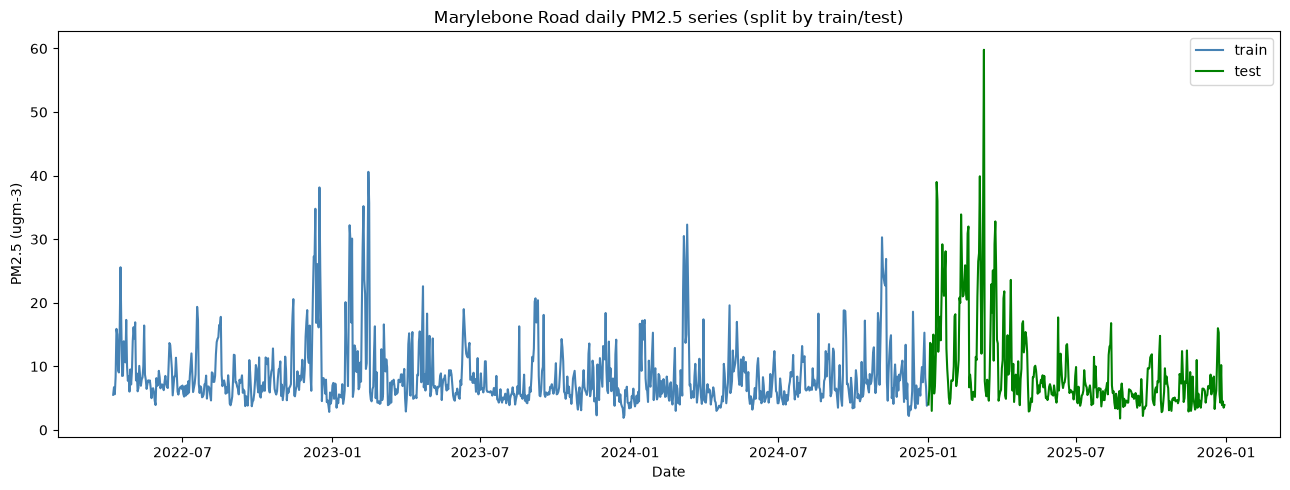

Saved: plots/marylebone_daily_pm25_splits.png


In [30]:
fig, ax = plt.subplots(figsize=(13, 5))
for split_name, color in zip(["train", "test"], ["steelblue", "green"]):
    sub = df[df["split"] == split_name]
    ax.plot(sub["date"], sub["pm25"], label=split_name, color=color)
ax.set_title("Marylebone Road daily PM2.5 series (split by train/test)")
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (ugm-3)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join("plots", "marylebone_daily_pm25_splits.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plots/marylebone_daily_pm25_splits.png")


## Note: scaling and normalization

Scaling is **not** applied in this notebook. Fit scalers at model-training time only:

- Within each CV fold: fit on that fold's training slice, then transform its hold-out slice.
- For the final model: fit on all of `train_df`, then transform `test_df`.

Never fit on the test set. Prefer scaling continuous features (pollutants, lags, rolls); leave cyclical encodings and binary flags as they are.


## Missing value check

Confirm there are no missing values across columns before exporting the splits.


In [31]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Rows: {len(df)}, columns: {df.shape[1]}")
if missing.empty:
    print("No missing values in any column.")
else:
    print(f"Columns with missing values ({len(missing)}):")
    print(missing.to_string())
    print(f"\nTotal missing cells: {int(missing.sum())}")


Rows: 1364, columns: 49
Columns with missing values (6):
CO      152
PM10     41
NO       23
NO2      23
NOx      23
O3       15

Total missing cells: 277


## Drop auxiliary pollutants

Several auxiliary pollutant features still have missing values after the target sync:

| Column | Missing rows |
|--------|-------------:|
| CO | 152 |
| PM10 | 41 |
| NO | 23 |
| NO2 | 23 |
| NOx | 23 |
| O3 | 15 |

We cannot train with missing inputs, so these columns are omitted for now. They may be added back later once gaps are imputed or otherwise handled.


In [32]:
aux_pollutants = ["CO", "PM10", "NO", "NO2", "NOx", "O3"]
df = df.drop(columns=aux_pollutants)

train_df = df[df["split"] == "train"].copy()
test_df = df[df["split"] == "test"].copy()

print(f"Dropped auxiliary pollutants: {aux_pollutants}")
print(f"Shape after drop: {df.shape}")


Dropped auxiliary pollutants: ['CO', 'PM10', 'NO', 'NO2', 'NOx', 'O3']
Shape after drop: (1364, 43)


In [33]:
#mean of training PM2.5
train_mean_pm25 = train_df["pm25"].mean()
print(f"Mean of training PM2.5: {train_mean_pm25:.3f} ug/m³")

Mean of training PM2.5: 8.490 ug/m³


In [35]:
#get test PM2.5 mean
test_mean_pm25 = test_df["pm25"].mean()
print(f"Mean of test PM2.5: {test_mean_pm25:.3f} ug/m³")

Mean of test PM2.5: 9.196 ug/m³


## Export splits

Write the chronological train/test tables (and the combined frame with a `split` label) for modelling.


In [ ]:
SPLIT_DIR = "../data/splits"
os.makedirs(SPLIT_DIR, exist_ok=True)

print("--- Marylebone combined feature splits ---")
for split_name, part in [("train", train_df), ("test", test_df)]:
    out = part.drop(columns=["split"], errors="ignore")
    out_path = os.path.join(SPLIT_DIR, f"marylebone_{split_name}.csv")
    out.to_csv(out_path, index=False)
    span = f"{out['date'].min().date()} -> {out['date'].max().date()}" if len(out) else "empty"
    print(f"  {split_name:5}: {len(out):4} rows ({span})  ->  {out_path}")

all_path = os.path.join(SPLIT_DIR, "marylebone_all.csv")
df.drop(columns=["split"], errors="ignore").to_csv(all_path, index=False)
print(f"  combined: {len(df)} rows  ->  {all_path}")
